In [1]:
from qiskit.circuit import QuantumCircuit
from pauliarray import PauliArray
from qiskit.quantum_info import Pauli, PauliList, Clifford
import numpy as np



In [2]:
bases = np.random.choice(['X', 'Y', 'Z'], size=(20, 4))
test = np.array(["".join(row) for row in bases])
paulis = PauliArray.from_labels(test)
# print(paulis.inspect())

In [3]:
qc = QuantumCircuit(3)
qc.x(0)
qc.x(0)
qc.measure_all()


print()


In [4]:
qc = QuantumCircuit(3)
qc.x(0)
# qc.x(0)
qc.measure_all()



In [5]:
arr = PauliArray.from_labels(["IIZXY"])
print(arr.size)

1


In [6]:
string = "SALUT"
print(list(string))

['S', 'A', 'L', 'U', 'T']


In [7]:
pau = np.array([
    ["I","X","Z","Y"],
    ["X","X","Y","Y"],
    ["I","I","I","Y"]
    ])

whe = [1,3]
wha= ["X","Y"]


# print(pau[:,whe])
# print(np.where(pau[:,whe]==wha))
# print(pau[:,whe]==wha)
print(np.where(np.apply_along_axis("".join, axis=1, arr=pau[:,whe])==np.apply_along_axis("".join, axis=0, arr=wha))[0])
print(np.where(np.all(pau[:,whe]==wha,axis=1))[0])


[0 1]
[0 1]


In [8]:
pauli = Pauli("XIXY")
index = [0,1,2]
print(np.array(list(pauli.to_label()))[index])

['X' 'I' 'X']


In [9]:
zero = np.zeros(5)
print(zero + 2)
pauli = PauliList(["ZIZZI"])
print(np.sum(np.logical_or(pauli.x,pauli.z),axis=-1))

[2. 2. 2. 2. 2.]
[3]


In [10]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

cliff = Clifford(qc)
print(cliff.destab_x)

[[False False]
 [False  True]]


In [18]:
from qiskit.circuit import AncillaRegister, QuantumRegister, Gate, ClassicalRegister

init_reg = QuantumRegister(4, 'psi')
bell = QuantumRegister(8, 'bell')
adjustments = ClassicalRegister(8, 'adj')

qc = QuantumCircuit(init_reg ,bell, adjustments)

# Préparation de l'état GHZ à téléporter
qc.h(init_reg[0])
for id in range(3):
    qc.cx(id,id+1)


def teleportation_gate() -> QuantumCircuit:
    psi  = QuantumRegister(1, 'psi')
    bell = QuantumRegister(2, 'bell')
    ajustments = ClassicalRegister(2, 'adj')

    qc = QuantumCircuit(psi, bell, ajustments)

    # Créer la paire de Bell entre bell[0] et bell[1]
    qc.h(bell[0])
    qc.cx(bell[0], bell[1])

    # Enchevêtrer psi avec bell[0]
    qc.cx(psi[0], bell[0])
    qc.h(psi[0])

    # Mesures
    qc.measure(psi[0],   ajustments[0])
    qc.measure(bell[0],  ajustments[1])

    # Corrections classiquement conditionnelles
    with qc.if_test((ajustments[1], 1)):
        qc.x(bell[1])

    with qc.if_test((ajustments[0], 1)):
        qc.z(bell[1])

    return qc

tp_gate = teleportation_gate()

for i in range(4):
    qc.compose(tp_gate, init_reg[i]+bell[i]+bell[4+i], adjustments[i] + adjustments[4+i], inplace=True)




qc.draw('mpl')


TypeError: unsupported operand type(s) for +: 'qiskit.circuit.Qubit' and 'qiskit.circuit.Qubit'

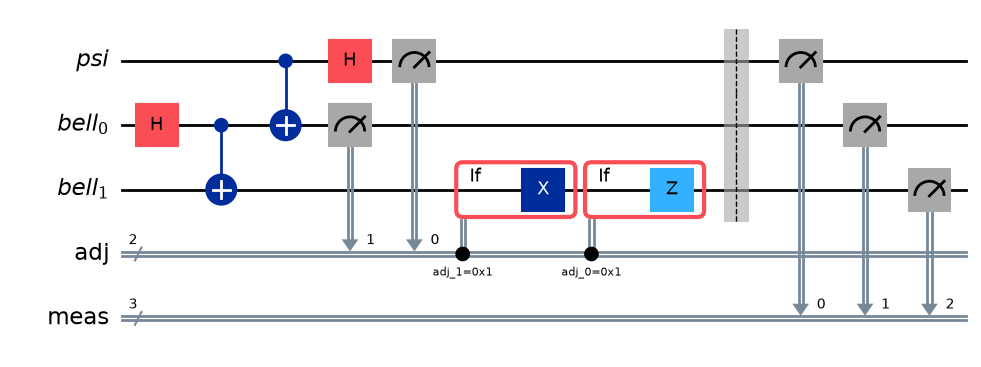

In [20]:
psi  = QuantumRegister(1, 'psi')
bell = QuantumRegister(2, 'bell')
ajustments = ClassicalRegister(2, 'adj')

qc = QuantumCircuit(psi, bell, ajustments)

# Créer la paire de Bell entre bell[0] et bell[1]
qc.h(bell[0])
qc.cx(bell[0], bell[1])

# Enchevêtrer psi avec bell[0]
qc.cx(psi[0], bell[0])
qc.h(psi[0])

# Mesures
qc.measure(psi[0],   ajustments[0])
qc.measure(bell[0],  ajustments[1])

# Corrections classiquement conditionnelles
with qc.if_test((ajustments[1], 1)):
    qc.x(bell[1])

with qc.if_test((ajustments[0], 1)):
    qc.z(bell[1])

qc.measure_all()
qc.draw('mpl')

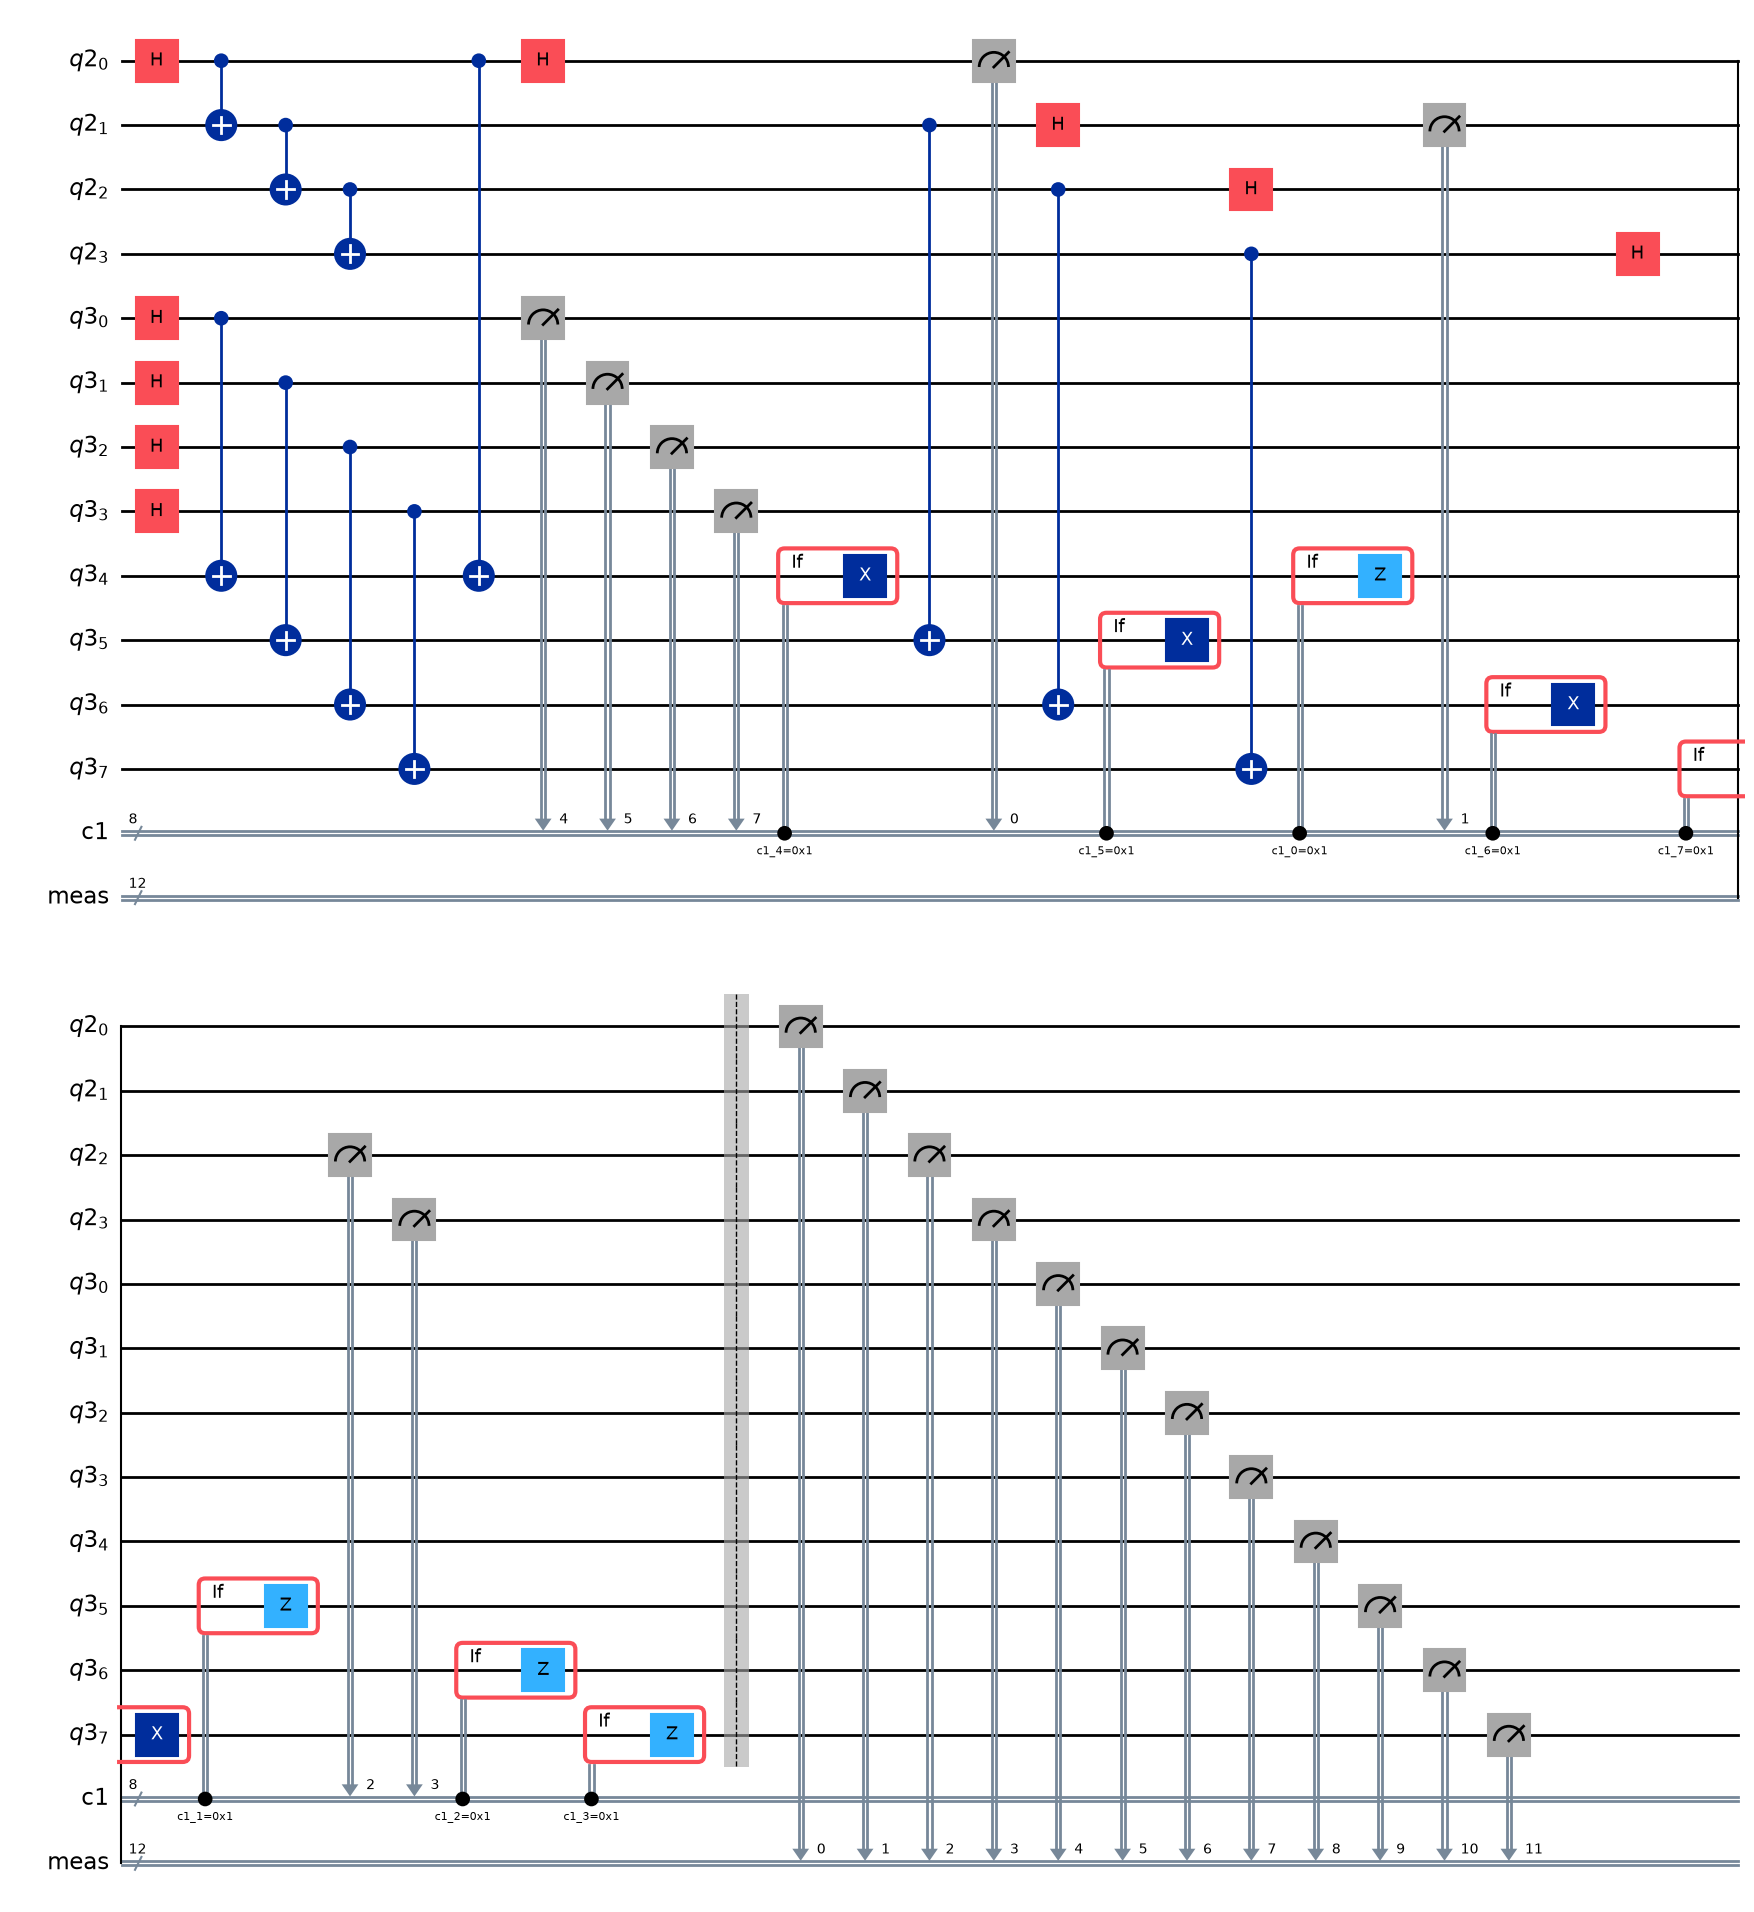

In [2]:
import numpy as np

from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister

# 4 qubit GHZ, 8 Bell
init_reg = QuantumRegister(4)
bells = QuantumRegister(8)
adj_reg = ClassicalRegister(8)

qc = QuantumCircuit(init_reg, bells, adj_reg)

# Preparation GHZ sur les 4 premiers qubits.
qc.h(init_reg[0])
for id in range(3):
    qc.cx(init_reg[id], init_reg[id + 1])

# Teleportation
for i in range(4):

    # Créer la paire de Bell entre bell[0] et bell[1]
    qc.h(bells[i])
    qc.cx(bells[i], bells[4 + i])

    # Enchevêtrer init_reg avec bells[i]
    qc.cx(init_reg[i], bells[4 + i])
    qc.h(init_reg[i])

    # Mesures
    qc.measure(init_reg[i], adj_reg[i])
    qc.measure(bells[i], adj_reg[4 + i])

    # Corrections classiquement conditionnelles
    with qc.if_test((adj_reg[4 + i], 1)):
        qc.x(bells[4 + i])

    with qc.if_test((adj_reg[i], 1)):
        qc.z(bells[4 + i])

qc.measure_all()
qc.draw("mpl")


In [1]:
import os

from qiskit import qpy
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Create output directory
os.makedirs("results/exp2_global", exist_ok=True)

# 4 qubit GHZ, 8 Bell
init_reg = QuantumRegister(4)
bells = QuantumRegister(8)
adj_reg = ClassicalRegister(8)

state_teleportated = QuantumCircuit(init_reg, bells, adj_reg)

# Preparation GHZ sur les 4 premiers qubits.
state_teleportated.h(init_reg[0])
for id in range(3):
    state_teleportated.cx(init_reg[id], init_reg[id + 1])

# Teleportation
for i in range(4):

    # Créer la paire de Bell entre bell[0] et bell[1]
    state_teleportated.h(bells[i])
    state_teleportated.cx(bells[i], bells[4 + i])

    # Enchevêtrer init_reg avec bells[i]
    state_teleportated.cx(init_reg[i], bells[4 + i])
    state_teleportated.h(init_reg[i])

    # Mesures
    state_teleportated.measure(init_reg[i], adj_reg[i])
    state_teleportated.measure(bells[4 + i], adj_reg[4 + i])

    # Corrections classiquement conditionnelles
    with state_teleportated.if_test((adj_reg[4 + i], 1)):
        state_teleportated.x(bells[i])

    with state_teleportated.if_test((adj_reg[i], 1)):
        state_teleportated.z(bells[i])


# Prepare the actual state in order to compare
state = QuantumCircuit(4)

state.h(0)
for id in range(3):
    state.cx(id, id + 1)

with open("results/exp2_global/state.qpy", "wb") as file:
    qpy.dump([state, state_teleportated], file)


print("Quantum circuits made successfuly\n")

state_teleportated.draw('mpl')

KeyboardInterrupt: 